# T3 (Tillson) — a quantitative teardown
### Daily total-return bars · T3(14, v=0.7) cross & slope · HAC inference · permutation placebo · SMA/EMA benchmarks · volume-factor sweep

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Genuinely_lower--lag%2C_cleaner_crossovers%3F: Mixed](https://img.shields.io/badge/Genuinely_lower--lag%2C_cleaner_crossovers%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the T3(14, v=0.7) price-cross (and slope) timing rule beats buy-and-hold on a net, excess-of-cash basis, beats the simpler SMA(14)/EMA(14) rules, fires fewer false signals, and does so genuinely faster — across five liquid daily tapes and every volume factor from 0.1 to 0.9.

> **Not investment advice.** Real data: Yahoo daily total-return bars, full history to 2026-06-30, as-of **2026-06-30**; the offline core runs the deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from t3_tillson import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2026-06-30"
T3_N, T3_V = 14, 0.7

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    b = data.load_real(t, fetch=False, cache_dir=CACHE)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | T3 active spread vs buy&hold **-3.4 bps/day**, HAC *t* = **-4.03** (gross *t* = -3.31); permutation *p* = **0.927**; negative across every v in [0.1, 0.9]. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.308** vs buy&hold **0.647**; loses gross; long/short Sharpe **-0.288**. |
| **Lower-lag, cleaner crossovers?** | `MIXED` | Cleaner: **true** (31.9 vs 36.5/38.3 switches/yr). Lower-lag: **false** (step-response value 105.29 vs SMA 108.57 / EMA 111.52). |

> In plain words: T3 is genuinely the calmest of the three lines, but it is also the laggiest — and neither property turns into a real trading edge.

## 1 · The claim, steelmanned

Let $\text{EMA}_n(x)$ be the exponential moving average (span convention) and define the *generalized DEMA*

$$\text{GD}(x, v) = (1+v)\,\text{EMA}_n(x) - v\,\text{EMA}_n(\text{EMA}_n(x)).$$

Tillson's T3 nests GD three times: $T3 = \text{GD}(\text{GD}(\text{GD}(P, v), v), v)$, which expands to a fixed linear combination of the 3rd–6th EMA of price. The hypotheses:

- **H₁ (signal).** $\mathbb{E}[\,r^{\text{strat}}_t - r^{\text{B\&H}}_t\,] > 0$ — the active spread is positive.
- **H₂ (beats SMA/EMA).** Net Sharpe$(T3) > $ Net Sharpe$(\text{SMA})$ and $>$ Net Sharpe$(\text{EMA})$, head-to-head active spread *t* ≥ 2.
- **H₃ (fewer false signals).** switches/yr$(T3) < $ switches/yr$(\text{SMA})$.
- **H₄ (lower lag).** T3 tracks a step in price faster than SMA/EMA at the same nominal N.

We reject H₁ (HAC *t* = -4.03) and H₂ (head-to-head *t* = 0.97 / 0.42, both < 2) and H₄ (T3 is the *slowest* of the three to a step); we **confirm H₃** (31.9 < 36.5 switches/yr, on every ticker).

## 2 · So what? — what rides on each answer

T3 is a textbook example of the desk's favorite trap: a filter that is *visibly* better on a chart (it really does track less noisily) being sold as *strictly* better on every axis, including the one axis (lag) it does not improve at a shared period. If H₁–H₄ all held it would be a Pareto improvement over both SMA and EMA — worth swapping into every existing strategy for free. Splitting the claim in two (smoother: yes; faster: no) is the point of testing the mechanism directly instead of taking the marketing at face value.

## 3 · How we'd know — the protocol

- **Indicator.** T3(14, v=0.7) — Tillson's own suggested volume factor, same nominal N as siblings 432/672 for a fair cross-study race; benchmarks SMA(14) and EMA(14).
- **Mechanism check.** A deterministic +20% step response and mean tracking distance |close − line|/close, isolated from any noise.
- **Rule.** Price-cross: $d_t = \mathbb{1}[C_t > T3_t]$ (and the same form for SMA/EMA); a **T3-slope** variant $d_t = \mathbb{1}[T3_t > T3_{t-1}]$. A long/short variant flips flat → −1.
- **Execution lag.** One `shift`: position formed on the close of $t$ earns the close-to-close return of $t+1$. Stated once, applied once.
- **Costs.** One-way × NAV on $|d_t - d_{t-1}|$ turnover; short legs pay 50 bps/yr borrow.
- **Signal test.** HAC (Newey-West) one-sample *t* on the daily *active spread* $r^{\text{strat}}-r^{\text{B\&H}}$ — excess-vs-excess by construction — plus head-to-head *t*'s vs SMA and EMA.
- **Placebo.** Circular-shift the realised position path 2,000× (kills timing, keeps turnover/bias); one-sided *p* on the gross spread.
- **Robustness.** Cost sweep, per-instrument, first-vs-second-half split, long/short, and a volume-factor v sweep across 0.1 → 0.9.
- **Positive control.** Synthetic tape with a *planted* regime-switching trend.

Five tapes: SPY, QQQ, AAPL, MSFT, XLE — full history to 2026-06-30 (SPY n = 8411).

## 4 · The teardown

### 4a · The mechanism check — is T3 actually lower-lag?

A clean +20% step in price (flat, then held) isolates the mechanism from any noise. Whichever line reaches the new level fastest genuinely has less lag.

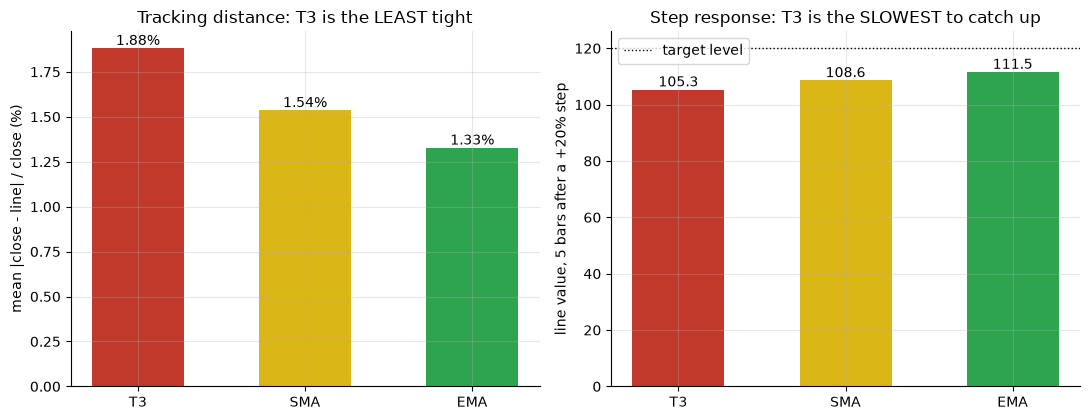

tracking distance: T3=1.881%  SMA=1.535%  EMA=1.327%
step value @+5: T3=105.29  SMA=108.57  EMA=111.52


In [2]:
if HAVE_REAL:
    td = st.tracking_distance(tape('SPY')['close'], n=T3_N, v=T3_V)
    sr = st.step_response(n=T3_N, v=T3_V)
    after5 = sr.iloc[35]
    dist = [td['T3'], td['SMA'], td['EMA']]
    step = [after5['T3'], after5['SMA'], after5['EMA']]
else:
    dist = [1.881, 1.535, 1.327]
    step = [105.29, 108.57, 111.52]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['T3','SMA','EMA'], dist, color=[RED, AMBER, GREEN], width=.55)
for i,v in enumerate(dist): a1.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('mean |close - line| / close (%)')
a1.set_title('Tracking distance: T3 is the LEAST tight')
a2.bar(['T3','SMA','EMA'], step, color=[RED, AMBER, GREEN], width=.55)
for i,v in enumerate(step): a2.annotate(f'{v:.1f}',(i,v),ha='center',va='bottom')
a2.axhline(120.0, c='k', lw=1, ls=':', label='target level')
a2.set_ylabel('line value, 5 bars after a +20% step')
a2.set_title('Step response: T3 is the SLOWEST to catch up'); a2.legend()
plt.tight_layout(); plt.show()
print(f'tracking distance: T3={dist[0]:.3f}%  SMA={dist[1]:.3f}%  EMA={dist[2]:.3f}%')
print(f'step value @+5: T3={step[0]:.2f}  SMA={step[1]:.2f}  EMA={step[2]:.2f}')

> In plain words: T3 sits **1.88%** away from price on average — farther than the SMA (1.53%) or EMA (1.33%) — and after a clean jump it is the *last* of the three to catch up. The reason is structural: T3 nests its DEMA-style lag correction three times, so by the third nesting the correction is being applied to an *already twice-smoothed* series, not raw price. Six stages of smoothing dominate the algebra at a shared N. This directly contradicts Tillson's "virtually eliminates lag" pitch when compared against a plain SMA/EMA of the same nominal length — the exact comparison every charting platform invites when a trader swaps the indicator but keeps the 'length' input.

### 4b · T3 vs SMA vs EMA vs buy-and-hold — net Sharpe and active-spread *t*

The bar that matters is the active-spread HAC *t*: if T3 timing helps, it clears +2.

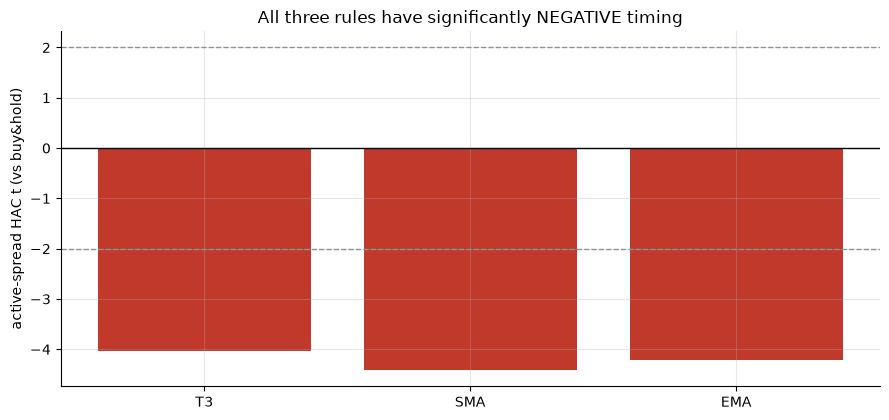

T3-SMA head-to-head t = +0.97   T3-EMA head-to-head t = +0.42


,rule,sharpe_net,spread_bps,spread_t,sw/yr
0,T3,0.308,-3.404,-4.030,31.878
1,SMA,0.238,-3.703,-4.416,36.462
2,EMA,0.267,-3.574,-4.216,38.320
3,B&H,0.647,0.000,NaN,0.000


In [3]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, sma_period=T3_N,
                            ema_period=T3_N, cost_bps=5.0)
    rows = [(k, res[k]['sharpe_net'], res[k]['mean_spread_bps'], res[k]['spread_t'],
             res[k]['switches_per_yr']) for k in ('T3','SMA','EMA')]
    rows.append(('B&H', res['T3']['bh_sharpe'], 0.0, float('nan'), 0.0))
    tbl = pd.DataFrame(rows, columns=['rule','sharpe_net','spread_bps','spread_t','sw/yr'])
    d_sma_t, d_ema_t = res['diff_t3_sma_t'], res['diff_t3_ema_t']
else:
    tbl = pd.DataFrame({
        'rule': ['T3','SMA','EMA','B&H'],
        'sharpe_net': [0.308,0.238,0.267,0.647],
        'spread_bps': [-3.4,-3.7,-3.57,0.0],
        'spread_t': [-4.03,-4.42,-4.22,float('nan')],
        'sw/yr': [31.9,36.5,38.3,0.0]})
    d_sma_t, d_ema_t = 0.97, 0.42
fig, ax = plt.subplots(figsize=(9.0, 4.3))
sub = tbl[tbl['rule']!='B&H']
col = [RED if t < 0 else GREY for t in sub['spread_t']]
ax.bar(sub['rule'], sub['spread_t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (vs buy&hold)')
ax.set_title('All three rules have significantly NEGATIVE timing')
plt.tight_layout(); plt.show()
print(f'T3-SMA head-to-head t = {d_sma_t:+.2f}   T3-EMA head-to-head t = {d_ema_t:+.2f}')
tbl.round(3)

> In plain words: every timing rule's active spread is significantly negative — none beats holding. T3 is the *best of the three* (*t* = -4.03, less negative than SMA's -4.42 or EMA's -4.22) but the head-to-head spread vs SMA (*t* = 0.97) and EMA (*t* = 0.42) never clears the desk's *t* ≥ 2 bar — T3 is not *measurably* better than the 'dumb' MAs it's meant to beat, only better by an uncertifiable margin.

### 4c · The whipsaw count — the one half of the claim that holds

Position changes per year, and the same count replicated across all five basket tickers.

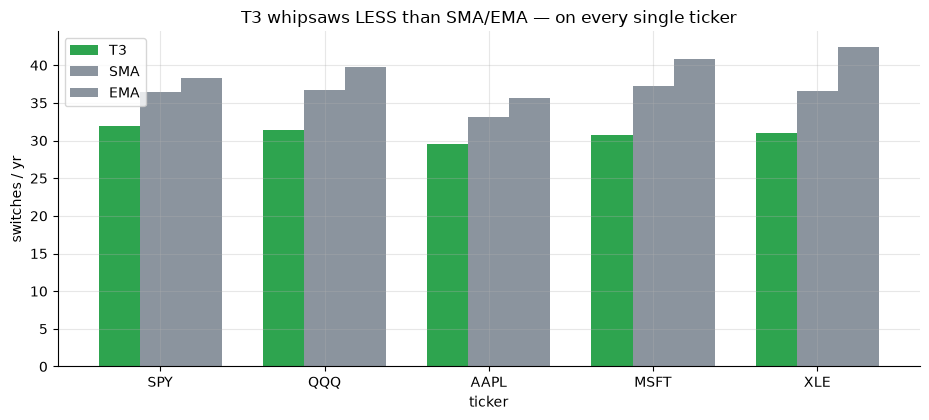

,T3,SMA,EMA
ticker,,,
SPY,31.9,36.5,38.3
QQQ,31.4,36.6,39.8
AAPL,29.6,33.1,35.7
MSFT,30.7,37.3,40.9
XLE,31.0,36.6,42.4


In [4]:
if HAVE_REAL:
    sw = {k: res[k]['switches_per_yr'] for k in ('T3','SMA','EMA')}
    per_sw = []
    for t in TICKERS:
        rr = st.run_experiment(tape(t), t3_n=T3_N, t3_v=T3_V, sma_period=T3_N,
                               ema_period=T3_N, cost_bps=5.0)
        per_sw.append((t, rr['T3']['switches_per_yr'], rr['SMA']['switches_per_yr'],
                       rr['EMA']['switches_per_yr']))
    per_sw = pd.DataFrame(per_sw, columns=['ticker','T3','SMA','EMA']).set_index('ticker')
else:
    sw = dict(T3=31.9, SMA=36.5, EMA=38.3)
    per_sw = pd.DataFrame({'T3': [31.9, 31.4, 29.6, 30.7, 31.0],
                           'SMA': [36.5, 36.6, 33.1, 37.3, 36.6],
                           'EMA': [38.3, 39.8, 35.7, 40.9, 42.4]},
                          index=['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'])
fig, ax = plt.subplots(figsize=(9.4, 4.3))
per_sw.plot(kind='bar', ax=ax, color=[GREEN, GREY, GREY], width=.75)
ax.set_ylabel('switches / yr'); ax.set_xticklabels(per_sw.index, rotation=0)
ax.set_title('T3 whipsaws LESS than SMA/EMA — on every single ticker')
plt.tight_layout(); plt.show()
per_sw.round(1)

> In plain words: 31.9 vs 36.5/38.3 switches/yr on SPY, and T3 is the calmest of the three on **all five** tickers — this is the one part of the pitch that genuinely holds up. Six stages of EMA smoothing really do damp noise; the failure is that this smoothness comes with more lag, not less, so the calmer line doesn't turn into a better trade.

### 4d · Permutation placebo — timing vs exposure

Circularly shift the realised position path 2,000×; the statistic is the gross active spread. If the timing is informative, the real spread beats the placebo distribution.

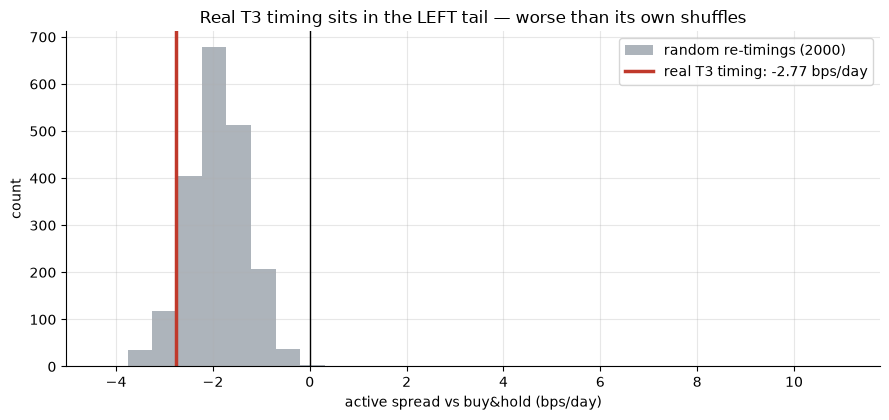

observed -2.77 | placebo mean -1.89 | one-sided p = 0.927


In [5]:
if HAVE_REAL:
    p = st.permutation_pvalue(tape('SPY')['close'].pct_change(),
                              st.t3_position(tape('SPY')['close'], T3_N, T3_V),
                              cost_bps=0.0, n_perm=2000, seed=673)
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
    rng = np.random.default_rng(673)
    a = tape('SPY')['close'].pct_change().fillna(0).to_numpy()
    held = st.t3_position(tape('SPY')['close'], T3_N, T3_V).shift(1).fillna(0).to_numpy()
    draws = []
    for _ in range(2000):
        h = np.roll(held, int(rng.integers(1,len(held))))
        turn=np.abs(np.diff(h,prepend=0.0)); draws.append(((h*a-turn*0)-a).mean()*1e4)
else:
    obs, plac, pv = -2.77, -1.89, 0.927
    draws = list(np.random.default_rng(1).normal(-1.89, 0.6, 2000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.7, label='random re-timings (2000)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real T3 timing: {obs:+.2f} bps/day')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('active spread vs buy&hold (bps/day)'); ax.set_ylabel('count')
ax.set_title('Real T3 timing sits in the LEFT tail — worse than its own shuffles')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} | placebo mean {plac:+.2f} | one-sided p = {pv:.3f}')

> In plain words: *p* = 0.927 — **92.7%** of random re-timings of T3's own trades beat the real ones. The timing isn't just uninformative; it is reliably on the wrong side more often than chance.

### 4e · Per-instrument, in/out-of-sample & long/short — is it ever positive?

Active-spread *t* on all five tapes, the SPY first-vs-second-half split, and the long/short variant.

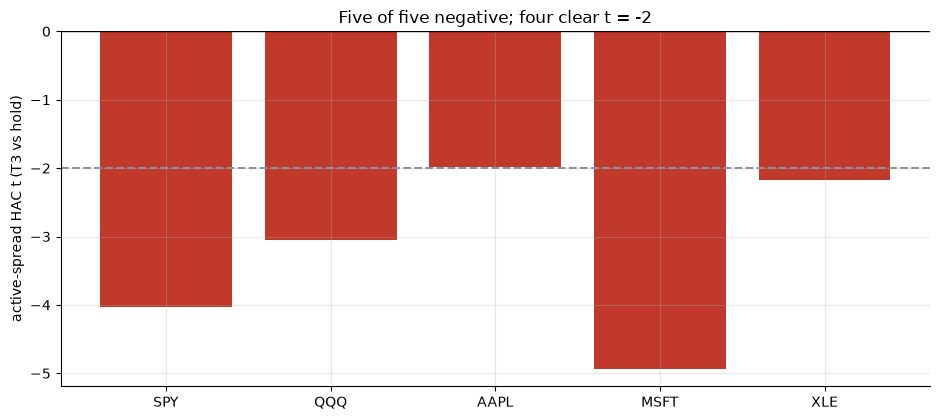

SPY split  H1 t = -2.99 | H2 t = -2.59  (both negative)
long/short: Sharpe -0.288, spread t = -4.08 (worse than long/flat)


,ticker,t3_sharpe,bh_sharpe,spread_bps,t
0,SPY,0.308,0.647,-3.404,-4.030
1,QQQ,0.227,0.521,-4.084,-3.049
2,AAPL,0.621,0.623,-3.486,-1.990
3,MSFT,0.519,0.821,-6.176,-4.944
4,XLE,0.219,0.428,-3.257,-2.170


In [6]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        rr = st.run_experiment(tape(t), t3_n=T3_N, t3_v=T3_V, cost_bps=5.0)['T3']
        recs.append((t, rr['sharpe_net'], rr['bh_sharpe'], rr['mean_spread_bps'], rr['spread_t']))
    per = pd.DataFrame(recs, columns=['ticker','t3_sharpe','bh_sharpe','spread_bps','t'])
    spy = tape('SPY'); half = len(spy)//2
    h1 = st.run_experiment(spy.iloc[:half], t3_n=T3_N, t3_v=T3_V, cost_bps=5.0)['T3']
    h2 = st.run_experiment(spy.iloc[half:], t3_n=T3_N, t3_v=T3_V, cost_bps=5.0)['T3']
    split = (h1['spread_t'], h2['spread_t'])
    ls = st.run_experiment(spy, t3_n=T3_N, t3_v=T3_V, cost_bps=5.0, long_short=True)['T3']
    ls_sharpe, ls_t = ls['sharpe_net'], ls['spread_t']
else:
    per = pd.DataFrame({'ticker': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 't3_sharpe': [0.308, 0.227, 0.621, 0.519, 0.219], 'bh_sharpe': [0.647, 0.521, 0.623, 0.821, 0.428], 'spread_bps': [-3.4, -4.08, -3.49, -6.18, -3.26], 't': [-4.03, -3.05, -1.99, -4.94, -2.17]})
    split = (-2.99, -2.59)
    ls_sharpe, ls_t = -0.288, -4.08
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(per['ticker'], per['t'], color=RED)
ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (T3 vs hold)')
ax.set_title('Five of five negative; four clear t = -2')
plt.tight_layout(); plt.show()
print('SPY split  H1 t = %.2f | H2 t = %.2f  (both negative)' % split)
print(f'long/short: Sharpe {ls_sharpe:+.3f}, spread t = {ls_t:+.2f} (worse than long/flat)')
per.round(3)

> In plain words: every instrument's T3 timing trails buy-and-hold, and SPY loses in both halves (H1 *t* = -2.99, H2 *t* = -2.59) — not a one-regime artefact. Shorting on the flip side makes it worse (Sharpe -0.288, *t* = -4.08).

### 4f · The T3-slope variant and the volume-factor (v) robustness sweep

The brief's other timer — long when T3 itself is rising — and Tillson's own tuning knob, swept from 0.1 to 0.9.

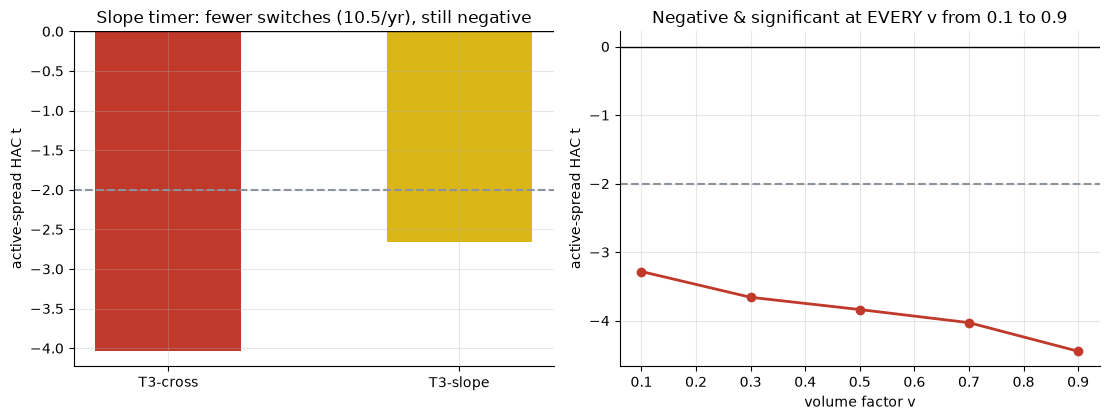

T3-slope: Sharpe +0.557, t = -2.66, 10.5 switches/yr
v-sweep t: {0.1: -3.28, 0.3: -3.66, 0.5: -3.84, 0.7: -4.03, 0.9: -4.45}


In [7]:
if HAVE_REAL:
    sl = st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, cost_bps=5.0, rule='slope')['T3']
    slope_sharpe, slope_t, slope_sw = sl['sharpe_net'], sl['spread_t'], sl['switches_per_yr']
    sweep = st.v_sweep(tape('SPY'), t3_n=T3_N, cost_bps=5.0)
    vs, vt, vsw = list(sweep.index), list(sweep['spread_t']), list(sweep['switches_per_yr'])
else:
    slope_sharpe, slope_t, slope_sw = 0.557, -2.66, 10.5
    vs, vt, vsw = [0.1, 0.3, 0.5, 0.7, 0.9], [-3.28, -3.66, -3.84, -4.03, -4.45], [20.5, 24.0, 28.5, 31.9, 33.8]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.3))
cross_t = res['T3']['spread_t'] if HAVE_REAL else -4.03
a1.bar(['T3-cross', 'T3-slope'], [cross_t, slope_t],
       color=[RED, AMBER], width=.5)
a1.axhline(-2, ls='--', c=GREY); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('active-spread HAC t'); a1.set_title(f'Slope timer: fewer switches ({slope_sw:.1f}/yr), still negative')
a2.plot(vs, vt, 'o-', c=RED, lw=2)
a2.axhline(-2, ls='--', c=GREY); a2.axhline(0, c='k', lw=1)
a2.set_xlabel('volume factor v'); a2.set_ylabel('active-spread HAC t')
a2.set_title('Negative & significant at EVERY v from 0.1 to 0.9')
plt.tight_layout(); plt.show()
print(f'T3-slope: Sharpe {slope_sharpe:+.3f}, t = {slope_t:+.2f}, {slope_sw:.1f} switches/yr')
print('v-sweep t:', {round(v,1): round(t,2) for v,t in zip(vs, vt)})

> In plain words: the T3-slope timer fires far fewer switches (10.5/yr — the smoothed line only flips on genuine reversals) and shrinks the loss (*t* = -2.66), but never crosses into positive, significant territory. And the volume-factor sweep closes the door on "maybe a different v would work": every v from 0.1 to 0.9 gives a negative, significant active spread (*t* between -4.45 and -3.28) — lower v (closer to a plain triple-EMA) is milder but never positive.

### 4g · Faithful-engine & power control — we know the truth here

Synthetic mean-reverting price tape, regime-switching planted trend. The null (edge=0) is checked over **20 seeds** — never a single stream.

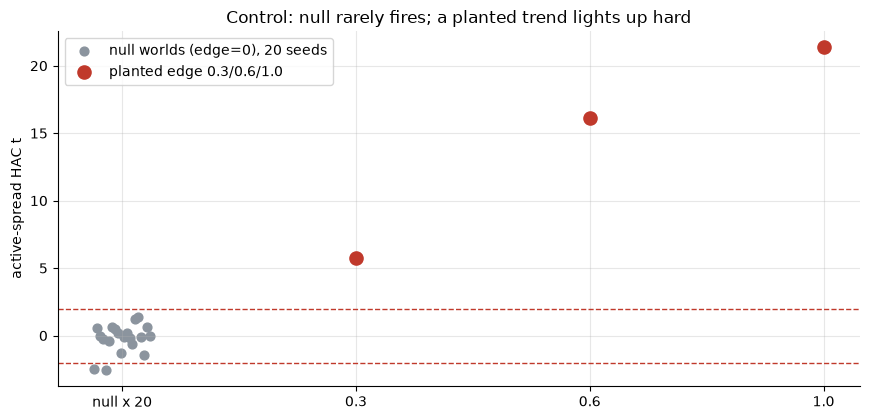

null: mean t = -0.21 (sd 1.05), |t|>=2 in 2/20 seeds  |  planted t = [5.757384910957494, 16.117257003108104, 21.353068004201276]


In [8]:
null_ts = []
for s_ in range(20):
    b, _ = data.synthetic_panel(n_days=6000, edge=0.0, seed=673 + s_)
    null_ts.append(st.run_experiment(b, t3_n=T3_N, t3_v=T3_V, cost_bps=0.0)['T3']['spread_t'])
null_ts = np.asarray(null_ts)
edges = [0.3, 0.6, 1.0]
planted_t = []
for e in edges:
    b, _ = data.synthetic_panel(n_days=6000, edge=e, seed=673)
    planted_t.append(st.run_experiment(b, t3_n=T3_N, t3_v=T3_V, cost_bps=0.0)['T3']['spread_t'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1,2,3], planted_t, color=RED, s=90, zorder=5, label='planted edge 0.3/0.6/1.0')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1,2,3]); ax.set_xticklabels(['null x 20','0.3','0.6','1.0'])
ax.set_ylabel('active-spread HAC t')
ax.set_title('Control: null rarely fires; a planted trend lights up hard')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t}')

> In plain words: across 20 null worlds the detector averages *t* = -0.21 (sd 1.05) and rarely crosses the bar (2/20 seeds); a planted trend of just 0.3 already reads *t* = +5.76, growing to +21.35 at edge=1.0. The machinery is unbiased and powerful — the real-tape null result is a statement about the market, not a broken harness. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — active spread -3.4 bps/day, HAC *t* -4.03 (gross -3.31); permutation *p* = 0.927; negative on 4/5 tapes individually, 5/5 point estimates, both halves, and every v in [0.1, 0.9].
- **Tradability `MIRAGE`** — net Sharpe 0.308 vs hold 0.647; loses gross; long/short Sharpe -0.288, spread -6.89 bps/day (*t* -4.08).
- **Lower-lag, cleaner crossovers? `MIXED`** — cleaner is true (31.9 vs 36.5/38.3 switches/yr, every ticker); lower-lag is false (slowest of three on a clean step, farthest mean tracking distance). Head-to-head vs SMA/EMA never clears *t* = 2 either way.

## 6 · Could you trade it? — the cost landscape

The spread is below zero before costs; there is no break-even, and the long/short version compounds the loss:

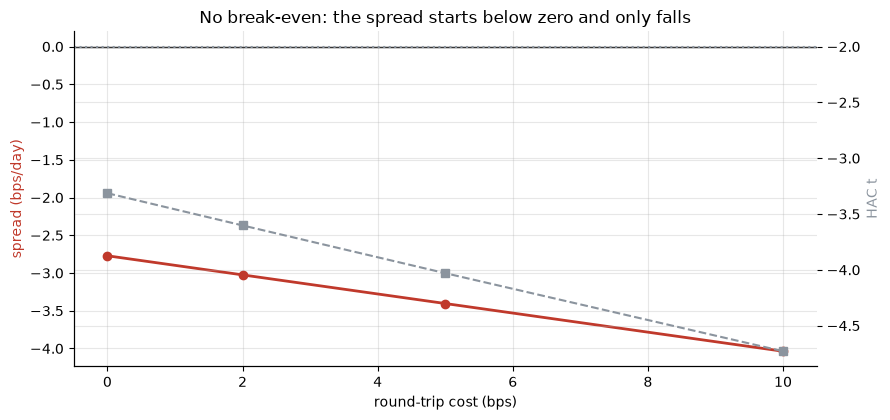

long/short net Sharpe: -0.288 (worse than long/flat)


In [9]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, cost_bps=c)['T3']['mean_spread_bps'] for c in costs]
    tst = [st.run_experiment(tape('SPY'), t3_n=T3_N, t3_v=T3_V, cost_bps=c)['T3']['spread_t'] for c in costs]
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.77, -3.02, -3.4, -4.04]; tst = [-3.31, -3.6, -4.03, -4.73]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2, label='active spread (bps/day)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('spread (bps/day)', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('No break-even: the spread starts below zero and only falls')
plt.tight_layout(); plt.show()
print('long/short net Sharpe: -0.288 (worse than long/flat)')

## 7 · Going further — the positive control, and what would change our mind

The synthetic control (4g) confirms the harness is unbiased and can bank a planted trend at *t* up to +21 — the null result above is about the market, not the machinery. What might rescue T3 for a future fork:

- **Shorter N.** Tillson himself sometimes suggests N in the 5-8 range to offset the six-stage smoothing — this study's "same nominal N as siblings 432/672" convention is fair for cross-study comparison, but a length-matched-for-lag comparison is a natural sequel.
- **Trend-prone assets.** Time-series momentum is a documented premium in futures and cross-asset baskets (Moskowitz, Ooi & Pedersen 2012); a single 37-year equity index tape may simply not hand any MA-based rule enough persistent trend to pay for its lag, T3 included.
- **The dedup map.** [Study 432 — Hull MA](../../432-hull-moving-average/) is the mirror image (less lag, more whipsaws); [Study 672 — McGinley Dynamic](../../672-mcginley-dynamic/) tests a recursive self-adjusting mechanism; [Study 483 — ZLEMA](../../483-zlema/), [Study 674 — VIDYA](../../674-vidya/) and [Study 433 — KAMA](../../433-kama-adaptive/) round out the "smarter MA" family with different adaptivity mechanisms.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*